# Conversion Rate Challenge — Prédiction des conversions

## Contexte

Le site **datascienceweekly.org** est une newsletter populaire animée par des data scientists indépendants.
Toute personne peut s'inscrire pour recevoir chaque semaine des actualités sur la data science.

L'équipe éditoriale souhaite **comprendre le comportement des visiteurs** de leur site et, en particulier,
déterminer s'il est possible de **prédire si un visiteur va s'abonner à la newsletter** (= *conversion*)
à partir de quelques informations simples le concernant.

## Pourquoi un apprentissage supervisé ?

Nous disposons d'un jeu de données **étiqueté** : pour chaque visiteur, on connaît la valeur de la cible
`converted` (0 = pas d'abonnement, 1 = abonnement). Le problème est donc une **classification binaire
supervisée** : on souhaite apprendre, à partir d'exemples passés, une fonction de décision capable de
prédire la classe d'un nouveau visiteur.

## Métrique d'évaluation

La métrique retenue est le **F1-score**. Ce choix est pertinent car les classes sont **fortement
déséquilibrées** (~3 % de conversions) : l'accuracy serait trompeuse (un modèle naïf prédisant
toujours 0 obtiendrait ~97 % d'accuracy). Le F1-score, moyenne harmonique de la précision et du
rappel, pénalise à la fois les faux positifs et les faux négatifs et constitue donc un indicateur
plus fiable pour évaluer la capacité du modèle à détecter les conversions.

## 1 · Import des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6",
                      "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"

import warnings
# Masque les avertissements non bloquants pour des sorties notebook plus lisibles (débug : retirer temporairement).
warnings.filterwarnings("ignore")

## 2 · Chargement et première exploration

In [2]:
data_train = pd.read_csv("conversion_data_train.csv")
data_test_unlabeled = pd.read_csv("conversion_data_test.csv")

print("Jeu d'entraînement :", data_train.shape)
print("Jeu de test (sans labels) :", data_test_unlabeled.shape)

Jeu d'entraînement : (284580, 6)
Jeu de test (sans labels) : (31620, 5)


In [3]:
data_train.head(10)

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0
5,US,29,0,Seo,7,0
6,US,30,1,Direct,4,0
7,UK,38,1,Ads,2,0
8,UK,26,1,Seo,4,0
9,UK,31,0,Seo,5,0


In [4]:
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   country              284580 non-null  str  
 1   age                  284580 non-null  int64
 2   new_user             284580 non-null  int64
 3   source               284580 non-null  str  
 4   total_pages_visited  284580 non-null  int64
 5   converted            284580 non-null  int64
dtypes: int64(4), str(2)
memory usage: 13.0 MB


In [5]:
data_train.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,284580,4,US,160124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,284580.0,NaN,NaN,NaN,30.564203,8.266789,17.0,24.0,30.0,36.0,123.0
new_user,284580.0,NaN,NaN,NaN,0.685452,0.464336,0.0,0.0,1.0,1.0,1.0
source,284580,3,Seo,139477,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_pages_visited,284580.0,NaN,NaN,NaN,4.873252,3.341995,1.0,2.0,4.0,7.0,29.0
converted,284580.0,NaN,NaN,NaN,0.032258,0.176685,0.0,0.0,0.0,0.0,1.0


In [6]:
print("Valeurs manquantes :\n", data_train.isnull().sum())
print("\nDoublons :", data_train.duplicated().sum())

Valeurs manquantes :
 country                0
age                    0
new_user               0
source                 0
total_pages_visited    0
converted              0
dtype: int64

Doublons : 268769


## 3 · Analyse exploratoire (EDA)

Le dataset contient ~284 000 lignes. Pour fluidifier les visualisations, on travaille sur un
échantillon représentatif.

In [7]:
SAMPLE_SIZE = 10_000
data_sample = data_train.sample(SAMPLE_SIZE, random_state=42)

### Distribution de la cible `converted`

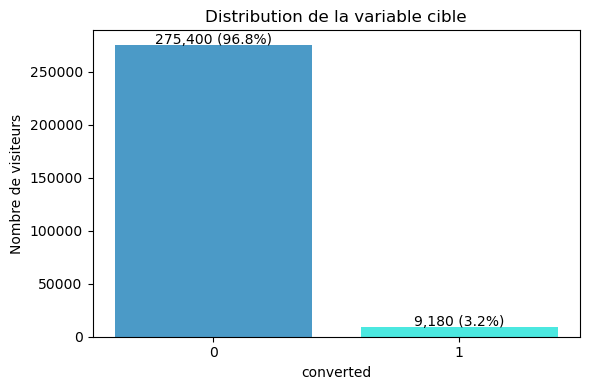

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = data_train["converted"].value_counts()
bars = ax.bar(counts.index.astype(str), counts.values, color=["#4B9AC7", "#4BE8E0"])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
            f"{val:,} ({val / len(data_train) * 100:.1f}%)", ha="center", fontsize=10)
ax.set_xlabel("converted")
ax.set_ylabel("Nombre de visiteurs")
ax.set_title("Distribution de la variable cible")
plt.tight_layout()
plt.show()

Le jeu de données est **très déséquilibré** : seulement ~3,2 % des visiteurs se sont abonnés.
Cela confirme l'importance d'utiliser le F1-score plutôt que l'accuracy.

### Taux de conversion par pays

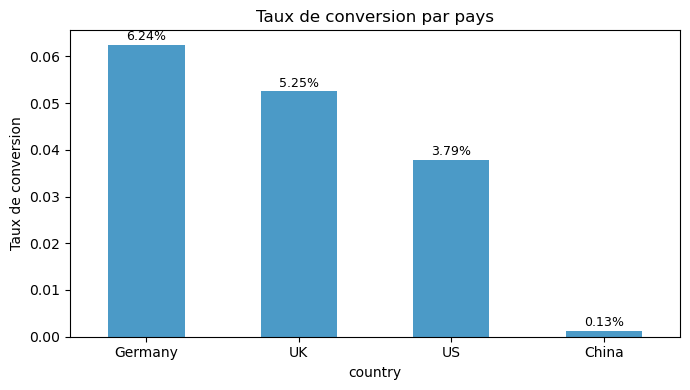

In [9]:
conv_by_country = data_train.groupby("country")["converted"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
conv_by_country.plot(kind="bar", ax=ax, color="#4B9AC7")
ax.set_ylabel("Taux de conversion")
ax.set_title("Taux de conversion par pays")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(conv_by_country.values):
    ax.text(i, v + 0.001, f"{v:.2%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### Distribution de l'âge par classe

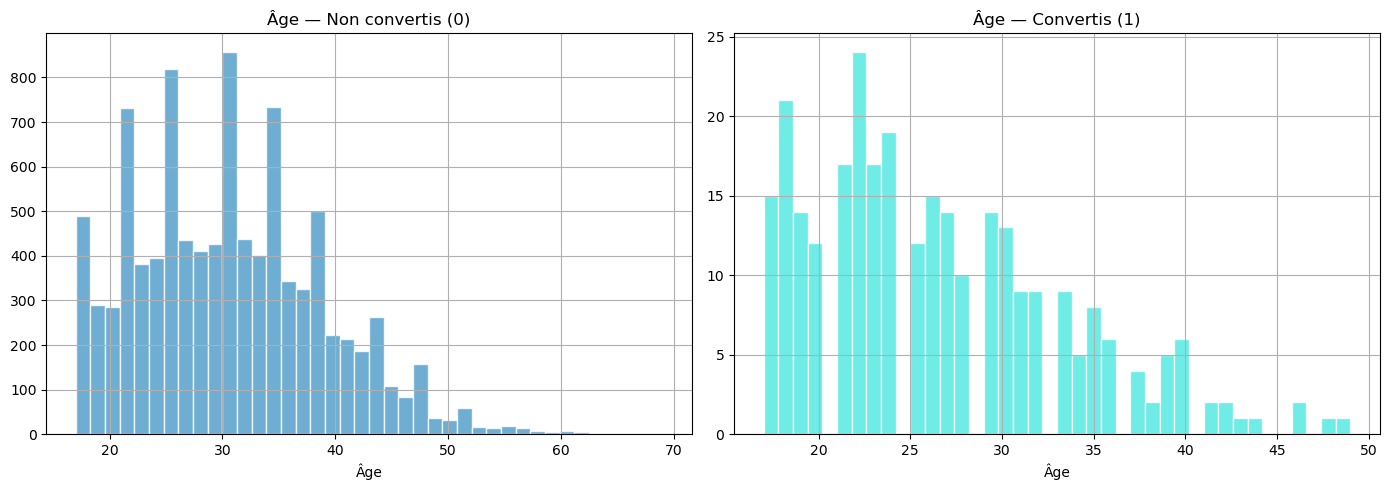

Statistiques d'âge :
              count       mean      std   min   25%   50%   75%    max
converted                                                             
0          275400.0  30.697422  8.27009  17.0  24.0  30.0  36.0   79.0
1            9180.0  26.567647  7.08539  17.0  21.0  25.0  31.0  123.0


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data_sample[data_sample["converted"] == 0]["age"].hist(
    bins=40, ax=axes[0], color="#4B9AC7", alpha=0.8, edgecolor="white")
axes[0].set_title("Âge — Non convertis (0)")
axes[0].set_xlabel("Âge")

data_sample[data_sample["converted"] == 1]["age"].hist(
    bins=40, ax=axes[1], color="#4BE8E0", alpha=0.8, edgecolor="white")
axes[1].set_title("Âge — Convertis (1)")
axes[1].set_xlabel("Âge")
plt.tight_layout()
plt.show()

print("Statistiques d'âge :")
print(data_train.groupby("converted")["age"].describe())

On observe des **valeurs aberrantes** dans l'âge (max = 123 ans). Les visiteurs convertis
semblent globalement plus jeunes. Dans la suite, nous **conservons l'âge tel quel** : les lignes sont rares et le pipeline (imputation médiane + standardisation) limite l'impact des extrêmes ; un filtrage explicite pourrait être ajouté dans une itération ultérieure.

### Taux de conversion par `new_user`

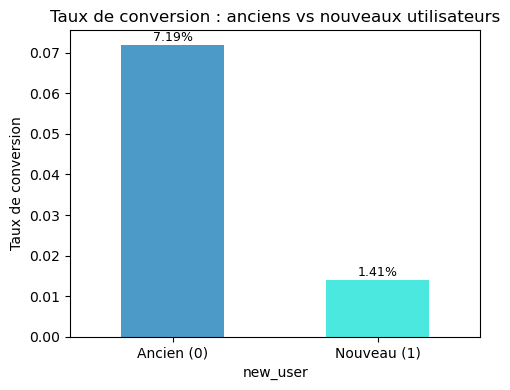

In [11]:
conv_by_user = data_train.groupby("new_user")["converted"].mean()
fig, ax = plt.subplots(figsize=(5, 4))
conv_by_user.plot(kind="bar", ax=ax, color=["#4B9AC7", "#4BE8E0"])
ax.set_ylabel("Taux de conversion")
ax.set_title("Taux de conversion : anciens vs nouveaux utilisateurs")
ax.set_xticklabels(["Ancien (0)", "Nouveau (1)"], rotation=0)
for i, v in enumerate(conv_by_user.values):
    ax.text(i, v + 0.001, f"{v:.2%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### Taux de conversion par `source`

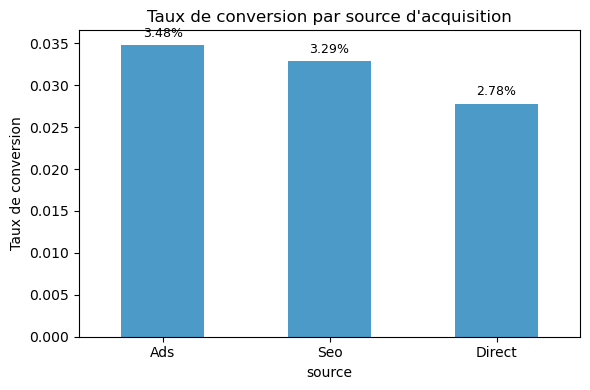

In [12]:
conv_by_source = data_train.groupby("source")["converted"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 4))
conv_by_source.plot(kind="bar", ax=ax, color="#4B9AC7")
ax.set_ylabel("Taux de conversion")
ax.set_title("Taux de conversion par source d'acquisition")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(conv_by_source.values):
    ax.text(i, v + 0.001, f"{v:.2%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### Distribution de `total_pages_visited` par classe

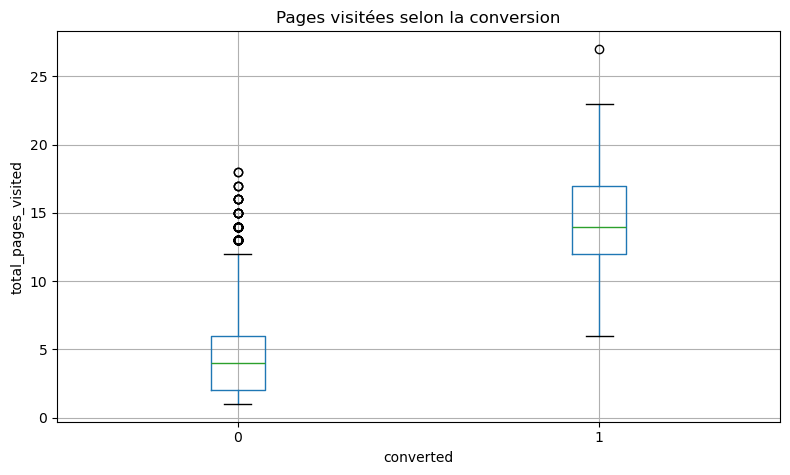

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
data_sample.boxplot(column="total_pages_visited", by="converted", ax=ax)
ax.set_xlabel("converted")
ax.set_ylabel("total_pages_visited")
ax.set_title("Pages visitées selon la conversion")
plt.suptitle("")
plt.tight_layout()
plt.show()

`total_pages_visited` est clairement le **facteur le plus discriminant** : les visiteurs
convertis consultent en moyenne beaucoup plus de pages que les non-convertis.

### Matrice de corrélation (variables numériques)

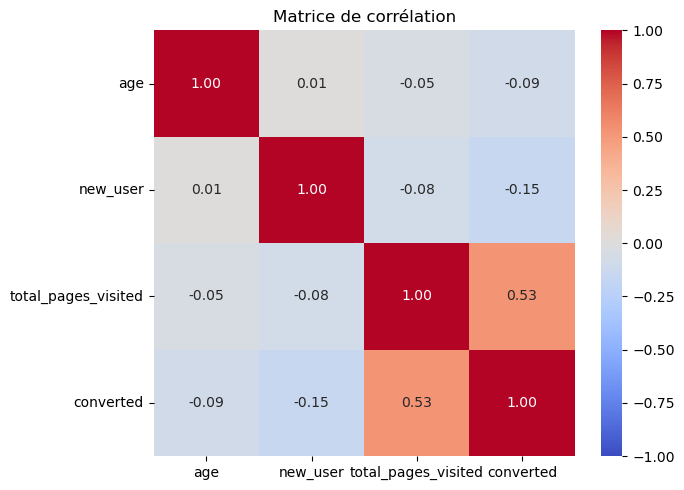

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = data_train[["age", "new_user", "total_pages_visited", "converted"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax, vmin=-1, vmax=1)
ax.set_title("Matrice de corrélation")
plt.tight_layout()
plt.show()

## 4 · Preprocessing et pipeline

Nous construisons un **pipeline scikit-learn** intégrant le preprocessing et le modèle,
afin d'éviter tout *data leak* lors de la validation croisée.

- **Variables numériques** (`age`, `total_pages_visited`) : `SimpleImputer(median)` → `StandardScaler`
- **Variables catégorielles** (`country`, `source`) : `SimpleImputer(most_frequent)` → `OneHotEncoder(drop='first')`
- **Variable binaire** (`new_user`) : passthrough (déjà encodée 0/1)

In [15]:
target = "converted"

numeric_features = ["age", "total_pages_visited"]
categorical_features = ["country", "source"]
passthrough_features = ["new_user"]

X = data_train[numeric_features + categorical_features + passthrough_features]
y = data_train[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} lignes")
print(f"Test  : {X_test.shape[0]} lignes")
print(f"Proportion cible train : {y_train.mean():.4f}")
print(f"Proportion cible test  : {y_test.mean():.4f}")

Train : 227664 lignes
Test  : 56916 lignes
Proportion cible train : 0.0323
Proportion cible test  : 0.0323


In [16]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
    ("pass", "passthrough", passthrough_features)
])

## 5 · Modèle baseline — Régression logistique

Premier modèle sans tuning, avec toutes les features. Il servira de **point de référence**
pour mesurer les progrès des modèles suivants.

In [17]:
baseline_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

baseline_pipe.fit(X_train, y_train)

y_train_pred = baseline_pipe.predict(X_train)
y_test_pred = baseline_pipe.predict(X_test)

f1_train_bl = f1_score(y_train, y_train_pred)
f1_test_bl = f1_score(y_test, y_test_pred)

print(f"F1-score train : {f1_train_bl:.4f}")
print(f"F1-score test  : {f1_test_bl:.4f}")
print()
print("Classification report (test) :")
print(classification_report(y_test, y_test_pred))
print("Matrice de confusion (test) :")
print(confusion_matrix(y_test, y_test_pred))

F1-score train : 0.7618
F1-score test  : 0.7678

Classification report (test) :
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     55080
           1       0.87      0.69      0.77      1836

    accuracy                           0.99     56916
   macro avg       0.93      0.84      0.88     56916
weighted avg       0.99      0.99      0.99     56916

Matrice de confusion (test) :
[[54886   194]
 [  571  1265]]


## 6 · Amélioration des modèles

Nous testons quatre algorithmes avec optimisation des hyperparamètres via **GridSearchCV**
(validation croisée 5-fold, scoring = F1-score).

### 6.1 · Régression logistique régularisée

In [18]:
pipe_lr = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {"classifier__C": [0.01, 0.1, 1, 10, 100]}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=5, scoring="f1", n_jobs=-1)
grid_lr.fit(X_train, y_train)

print(f"Meilleur C : {grid_lr.best_params_['classifier__C']}")
print(f"Meilleur F1 CV : {grid_lr.best_score_:.4f}")

y_test_pred_lr = grid_lr.predict(X_test)
f1_test_lr = f1_score(y_test, y_test_pred_lr)
print(f"F1-score test : {f1_test_lr:.4f}")

Meilleur C : 1
Meilleur F1 CV : 0.7616
F1-score test : 0.7678


### 6.2 · Arbre de décision

In [19]:
pipe_dt = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    "classifier__max_depth": [3, 5, 7, 10, 15],
    "classifier__min_samples_split": [2, 5, 10, 20]
}

grid_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=5, scoring="f1", n_jobs=-1)
grid_dt.fit(X_train, y_train)

print(f"Meilleurs paramètres : {grid_dt.best_params_}")
print(f"Meilleur F1 CV : {grid_dt.best_score_:.4f}")

y_test_pred_dt = grid_dt.predict(X_test)
f1_test_dt = f1_score(y_test, y_test_pred_dt)
print(f"F1-score test : {f1_test_dt:.4f}")

Meilleurs paramètres : {'classifier__max_depth': 10, 'classifier__min_samples_split': 10}
Meilleur F1 CV : 0.7418
F1-score test : 0.7513


### 6.3 · Random Forest

In [20]:
pipe_rf = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, 15, None]
}

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=5, scoring="f1", n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(f"Meilleurs paramètres : {grid_rf.best_params_}")
print(f"Meilleur F1 CV : {grid_rf.best_score_:.4f}")

y_test_pred_rf = grid_rf.predict(X_test)
f1_test_rf = f1_score(y_test, y_test_pred_rf)
print(f"F1-score test : {f1_test_rf:.4f}")

Meilleurs paramètres : {'classifier__max_depth': 10, 'classifier__n_estimators': 100}
Meilleur F1 CV : 0.7530
F1-score test : 0.7579


### 6.4 · Gradient Boosting

In [21]:
pipe_gb = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

param_grid_gb = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1, 0.2],
    "classifier__max_depth": [3, 5]
}

grid_gb = GridSearchCV(pipe_gb, param_grid_gb, cv=5, scoring="f1", n_jobs=-1)
grid_gb.fit(X_train, y_train)

print(f"Meilleurs paramètres : {grid_gb.best_params_}")
print(f"Meilleur F1 CV : {grid_gb.best_score_:.4f}")

y_test_pred_gb = grid_gb.predict(X_test)
f1_test_gb = f1_score(y_test, y_test_pred_gb)
print(f"F1-score test : {f1_test_gb:.4f}")

Meilleurs paramètres : {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
Meilleur F1 CV : 0.7607
F1-score test : 0.7627


### 6.5 · Tableau comparatif

In [22]:
results = pd.DataFrame({
    "Modèle": [
        "Baseline (LogReg)",
        "LogReg régularisée",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "F1 Train": [
        f1_score(y_train, baseline_pipe.predict(X_train)),
        f1_score(y_train, grid_lr.predict(X_train)),
        f1_score(y_train, grid_dt.predict(X_train)),
        f1_score(y_train, grid_rf.predict(X_train)),
        f1_score(y_train, grid_gb.predict(X_train)),
    ],
    "F1 Test": [
        f1_test_bl,
        f1_test_lr,
        f1_test_dt,
        f1_test_rf,
        f1_test_gb,
    ],
    "Précision Test": [
        classification_report(y_test, y_test_pred, output_dict=True)["1"]["precision"],
        classification_report(y_test, y_test_pred_lr, output_dict=True)["1"]["precision"],
        classification_report(y_test, y_test_pred_dt, output_dict=True)["1"]["precision"],
        classification_report(y_test, y_test_pred_rf, output_dict=True)["1"]["precision"],
        classification_report(y_test, y_test_pred_gb, output_dict=True)["1"]["precision"],
    ],
    "Rappel Test": [
        classification_report(y_test, y_test_pred, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_test_pred_lr, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_test_pred_dt, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_test_pred_rf, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_test_pred_gb, output_dict=True)["1"]["recall"],
    ],
})

results = results.sort_values("F1 Test", ascending=False).reset_index(drop=True)
results.style.format({
    "F1 Train": "{:.4f}", "F1 Test": "{:.4f}",
    "Précision Test": "{:.4f}", "Rappel Test": "{:.4f}"
}).highlight_max(subset=["F1 Test"], color="#4BE8E0")

,Modèle,F1 Train,F1 Test,Précision Test,Rappel Test
0,Baseline (LogReg),0.7618,0.7678,0.8670,0.6890
1,LogReg régularisée,0.7618,0.7678,0.8670,0.6890
2,Gradient Boosting,0.7617,0.7627,0.8610,0.6846
3,Random Forest,0.7797,0.7579,0.8624,0.6759
4,Decision Tree,0.7733,0.7513,0.8569,0.6688


### 6.6 · Validation croisée du meilleur modèle

In [23]:
best_model_name = results.loc[0, "Modèle"]
print(f"Meilleur modèle : {best_model_name}")

grids = {
    "Baseline (LogReg)": baseline_pipe,
    "LogReg régularisée": grid_lr.best_estimator_,
    "Decision Tree": grid_dt.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
    "Gradient Boosting": grid_gb.best_estimator_,
}
best_estimator = grids[best_model_name]

cv_scores = cross_val_score(best_estimator, X_train, y_train, cv=5, scoring="f1", n_jobs=-1)
print(f"\nF1-scores par fold : {cv_scores.round(4)}")
print(f"F1 moyen (CV 5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Meilleur modèle : Baseline (LogReg)

F1-scores par fold : [0.7513 0.7599 0.7613 0.7696 0.7656]
F1 moyen (CV 5-fold) : 0.7616 ± 0.0062


## 7 · Analyse du meilleur modèle

### Feature importances

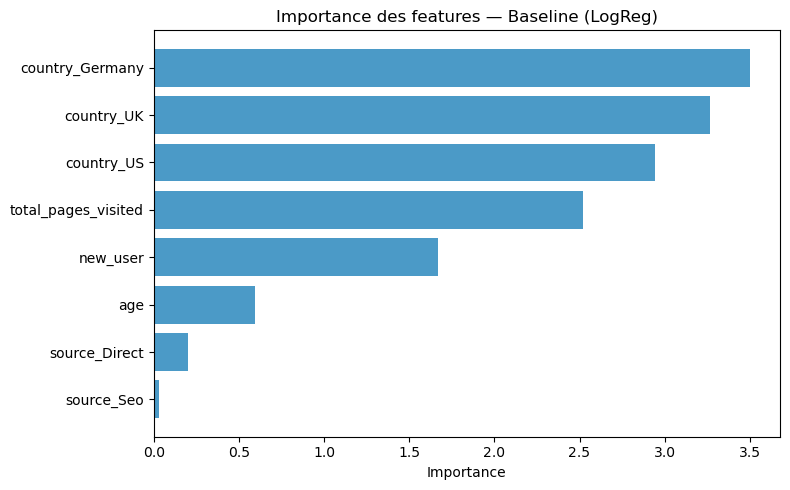

In [24]:
best_pipe = grids[best_model_name]
classifier = best_pipe.named_steps["classifier"]
prep = best_pipe.named_steps["preprocessing"]

feature_names = (
    numeric_features
    + list(prep.named_transformers_["cat"]
           .named_steps["encoder"]
           .get_feature_names_out(categorical_features))
    + passthrough_features
)

if hasattr(classifier, "feature_importances_"):
    importances = classifier.feature_importances_
elif hasattr(classifier, "coef_"):
    importances = np.abs(classifier.coef_[0])
else:
    importances = None

if importances is not None:
    imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=True)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(imp_df["Feature"], imp_df["Importance"], color="#4B9AC7")
    ax.set_title(f"Importance des features — {best_model_name}")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

### Matrice de confusion du meilleur modèle

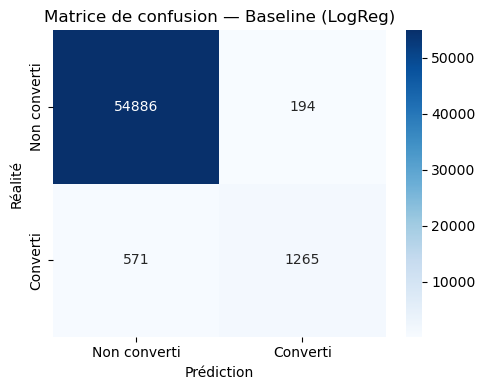

              precision    recall  f1-score   support

Non converti       0.99      1.00      0.99     55080
    Converti       0.87      0.69      0.77      1836

    accuracy                           0.99     56916
   macro avg       0.93      0.84      0.88     56916
weighted avg       0.99      0.99      0.99     56916



In [25]:
y_best_pred = best_pipe.predict(X_test)

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_best_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Non converti", "Converti"],
            yticklabels=["Non converti", "Converti"])
ax.set_xlabel("Prédiction")
ax.set_ylabel("Réalité")
ax.set_title(f"Matrice de confusion — {best_model_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_best_pred, target_names=["Non converti", "Converti"]))

### Recommandations business

Sur la base de l'analyse des features les plus importantes du modèle, voici les recommandations
pour améliorer le taux de conversion de la newsletter :

1. **Optimiser l'expérience de navigation** : `total_pages_visited` est de loin la feature la plus
   discriminante. Plus un visiteur consulte de pages, plus il a de chances de s'abonner. Il faut
   donc encourager l'exploration du site (articles recommandés, liens internes, contenu engageant).

2. **Cibler les anciens utilisateurs** : les visiteurs récurrents (`new_user = 0`) convertissent
   mieux que les nouveaux. Investir dans des campagnes de réengagement (emails de relance, notifications)
   pourrait augmenter le taux de conversion.

3. **Adapter la stratégie par pays** : les taux de conversion varient selon le pays. Une localisation
   du contenu ou des offres ciblées par zone géographique pourraient améliorer les résultats dans les
   pays à faible conversion.

4. **Segmenter par tranche d'âge** : les profils d'âge des convertis diffèrent de ceux des non-convertis.
   Personnaliser le message marketing selon l'âge du visiteur (contenu, design, canal d'acquisition)
   pourrait être un levier efficace.

5. **Diversifier les sources d'acquisition** : analyser le ROI par source (SEO, Ads, Direct) et
   réallouer le budget vers les canaux les plus performants en termes de conversion effective.

## 8 · Prédictions sur le jeu de test

On ré-entraîne le meilleur modèle sur **l'ensemble des données étiquetées** pour maximiser
la quantité d'information utilisée, puis on prédit sur le fichier `conversion_data_test.csv`.

In [26]:
X_full = data_train[numeric_features + categorical_features + passthrough_features]
y_full = data_train[target]

best_pipe.fit(X_full, y_full)
print("Modèle ré-entraîné sur l'ensemble des données étiquetées.")

Modèle ré-entraîné sur l'ensemble des données étiquetées.


In [27]:
X_submit = data_test_unlabeled[numeric_features + categorical_features + passthrough_features]
predictions = best_pipe.predict(X_submit)

submission = pd.DataFrame({"converted": predictions})
output_file = "conversion_data_test_predictions_challenge.csv"
submission.to_csv(output_file, index=False)

print(f"Fichier exporté : {output_file}")
print(f"Nombre de prédictions : {len(predictions)}")
print(f"Distribution des prédictions :\n{submission['converted'].value_counts()}")

Fichier exporté : conversion_data_test_predictions_challenge.csv
Nombre de prédictions : 31620
Distribution des prédictions :
converted
0    30800
1      820
Name: count, dtype: int64


## 9 · Conclusion

### Résumé des résultats

- Nous avons construit et comparé **cinq modèles** de classification binaire pour prédire les
  conversions sur le site datascienceweekly.org.
- Le modèle baseline (régression logistique sans tuning) a servi de point de référence ; les autres
  familles (régression régularisée, arbres, Random Forest, Gradient Boosting) ont été comparées sur le **F1-score** du jeu de test.
- Le **modèle retenu pour la soumission** est celui qui obtient le meilleur F1 sur ce hold-out (pas
  une supposition a priori sur la « complexité » du modèle).
- Le **GridSearchCV** avec validation croisée 5-fold a permis d'optimiser les hyperparamètres de
  chaque modèle candidat.
- La feature `total_pages_visited` est de loin la plus prédictive, suivie de `new_user` et `age`.

### Limites et pistes d'amélioration

- **Déséquilibre des classes** : les modèles scikit-learn utilisés permettent d'explorer le paramètre
  `class_weight` (pondération des classes) pour mieux prendre en compte la classe minoritaire, dans
  le même pipeline.
- **Feature engineering** : enrichir les entrées (interactions simples, tranches d'âge, regroupements
  de catégories) pourrait améliorer le signal sans changer l'architecture générale du preprocessing.
- **Hyperparamètres** : élargir ou affiner les valeurs testées dans `GridSearchCV` sur les familles de
  modèles déjà choisies.